# Tp 2 : Optimisation sans contrainte et descente de gradient

### Objectifs pédagogiques du TP
Dans cette séance de travaux pratiques, nous allons :
1. Construire un modèle mathématique d’un problème réel d’optimisation.
2. Étudier l’existence et l’unicité de la solution dans un problème sans contrainte.
3. Implémenter la descente de gradient :
    * Descente de gradient batch (BGD)
    * Descente de gradient stochastique simplifiée (SGD)
4. Observer l’influence du taux d’apprentissage et des paramètres du modèle.

### Table
- [1. Description du problème](#1)
- [2. Génération de la trajectoire initiale](#2)
- [3. Modélisation mathématique](#3)
    - [3.1 Fonction Objective](#3.1)
    - [3.2. Questions théoriques](#3.2)
    - [3.3. Implémentation de la fonction objectif](#3.3)
- [4. Approximation numérique du gradient](#4)
    - [4.1 Descente de gradient (BGD)](#4.1)
    - [4.2 Descente de gradient stochastique (SGD)](#4.2)
    - [4.3 Comparaison de BGD et SGD](#4.3)
- [5. Analyse expérimentale](#5)
- [6. Conclusion](#6)

<a name='1'></a>
### 1. Description du problème
On considère un problème de planification de trajectoire dans un espace tridimensionnel.
Un drone doit relier plusieurs points tout en :
* minimisant la longueur de la trajectoire ;
* gardant une trajectoire lisse ;
* évitant des obstacles sphériques.
La trajectoire est représentée par :
$$\mathbf{x} =[\mathbf{x}_1,\mathbf{x}_2,\dots,\mathbf{x}_N]^\top$$
où
$$\mathbf{x}_i=(x_i,y_i,z_i)$$
désigne le (i)-ème point de la trajectoire.

**Configuration des obstacles** : Supposons qu'il y ait plusieurs obstacles sphériques dans l'espace tridimensionnel, par exemple :
1. Obstacle 1 :
    - Centre $c_1 = (1,5,\, 1,5,\, 1,5)$
    - Rayon $r_1 = 0,5$
1. Obstacle 2 :
    - Centre $c_2 = (2,5,\, 2,5,\, 2,5)$
    - Rayon $r_2 = 0,5$

<a name='2'></a>

### 2. Génération de la trajectoire initiale
Nous générons aléatoirement $N$ points dans l'espace tridimensionnel comme trajectoire initiale, par exemple $N=10$ :
$$\mathbf{x}_{\text{init}} = \text{ points aléatoires dans } [0,3]^3$$

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

# Générer des points initiaux aléatoires
N = 10  # Nombre de points
np.random.seed(37)
x_init = np.random.rand(N, 3) * 3  # Points dans [0, 3]^3
x_init[0] = np.array([0,0,0])
x_init[-1] = np.array([3,3,3])
x0 = x_init.flatten()

# Configuration des obstacles
obstacles = [
    {"center": np.array([1.5, 1.5, 1.5]), "radius": 0.5},
    {"center": np.array([2.5, 2.5, 2.5]), "radius": 0.5}
]

print(x_init)

[[0.         0.         0.        ]
 [1.74568463 1.86025263 2.05267205]
 [0.31031267 2.2364273  0.84593721]
 [2.26027376 2.37811689 1.88220179]
 [1.33046653 2.89039606 2.69119966]
 [0.59041286 1.7878534  1.72013084]
 [2.11484806 2.78778606 0.15368949]
 [0.40443597 0.35108552 1.09417428]
 [2.41023251 2.91072816 0.99893778]
 [3.         3.         3.        ]]


<a name='3'></a>

### 3. Modélisation mathématique

<a name='3.1'></a>

#### 3.1 Fonction Objective

Nous définissons une fonction coût composée de trois parties :
1. Minimiser la longueur de la trajectoire (réduire la consommation d'énergie).
1. Minimiser la courbure de la trajectoire (réduire les changements d'accélération).
1. Éviter les collisions avec les obstacles (grâce à une forte pénalité).

--------------------------------------- Réponse à remplir ---------------------------------------

**Fonction objective** :

**1. Longueur de trajectoire**
$$L_{\mathrm{traj}}(\mathbf{x}) = \sum_{i=1}^{N-1} \|\mathbf{x}_{i+1}-\mathbf{x}_i\|$$
Cette partie représente la consommation d’énergie.

**2. Régularité / Lissage**
$$C_{\mathrm{courbure}}(\mathbf{x}) = \sum_{i=2}^{N-1} \|\mathbf{x}_{i+1}-2\mathbf{x}_i+\mathbf{x}_{i-1}\|^2$$
Cette quantité pénalise les changements brusques de direction.

**3. Pénalité de collision**
Pour chaque obstacle sphérique :
$$d_i = \|\mathbf{x}_i-c\|$$
si $d_i \le r$, alors une pénalité est ajoutée :
$$P_{\mathrm{collision}}(\mathbf{x}) = \sum_i \max(0,r-d_i)^2$$

**Fonction objectif finale**
$$J(\mathbf{x}) = \alpha L_{\mathrm{traj}}(\mathbf{x}) + \beta C_{\mathrm{courbure}}(\mathbf{x}) + \gamma P_{\mathrm{collision}}(\mathbf{x})$$
où :
* $\alpha$ : importance de la longueur ;
* $\beta$ : importance du lissage ;
* $\gamma$ : importance de l’évitement d’obstacle.

---------------------------------------------- Fin ----------------------------------------------

<a name='3.2'></a>

#### 3.2. Questions théoriques
**Question 1 — Existence d’une solution**

Montrer que la fonction objectif est continue.
*Indication :*
- la norme euclidienne est continue ;
- une somme de fonctions continues reste continue.

--------------------------------------- Réponse à remplir ---------------------------------------

Nous allons démontrer que :
$$J(\mathbf{x})$$
est continue.

- Étape 1 — Continuité de la norme euclidienne
    La norme euclidienne
    $\|x\| = \sqrt{x_1^2+x_2^2+x_3^2}$
    est continue car :
    * les polynômes sont continus ;
    * la racine carrée est continue sur $\mathbb{R}_+$ ;
    * une composition de fonctions continues reste continue.
    
    Donc :
    $\|\mathbf{x}_{i+1}-\mathbf{x}_i\|$
    est continue.

- Étape 2 — Continuité du terme de longueur
    Le terme :
    $$L_{\mathrm{traj}}(\mathbf{x})
    = \sum_{i=1}^{N-1}\|\mathbf{x}_{i+1}-\mathbf{x}_i\|$$
    est une somme finie de fonctions continues.
    
    Donc :
    $L_{\mathrm{traj}}$
    est continue.

- Étape 3 — Continuité du terme de courbure
    Considérons :
    $$\mathbf{x}_{i+1}-2\mathbf{x}_i+\mathbf{x}_{i-1}$$
    Cette expression est affine par rapport aux variables.
    Or :
    * les fonctions affines sont continues ;
    * la norme est continue ;
    * le carré d’une fonction continue reste continu.
    Ainsi :
    $$\|\mathbf{x}_{i+1}-2\mathbf{x}_i+\mathbf{x}_{i-1}\|^2$$
    est continue.
    
    Comme il s’agit d’une somme finie :
    $C_{\mathrm{courbure}}$
    est continue.

- Étape 4 — Continuité du terme de collision
    Nous avons :
    $d_i=\|\mathbf{x}_i-c\|$
    qui est continue.

    Ensuite :
    $r-d_i$
    est continue.

    Puis :
    $\max(0,r-d_i)$
    est continue car le maximum de deux fonctions continues est continu.

    Enfin :
    $\max(0,r-d_i)^2$
    reste continue.

    Donc :
    $P_{\mathrm{collision}}$
    est continue.

- Conclusion
    La fonction objectif :
    $$J(\mathbf{x})
    = \alpha L_{\mathrm{traj}}+\beta C_{\mathrm{courbure}}+\gamma P_{\mathrm{collision}}$$
    est combinaison linéaire de fonctions continues.

    Donc :
    $$\boxed{J(\mathbf{x})\text{ est continue.}}$$

---------------------------------------------- Fin ----------------------------------------------

**Question 2 — Existence d’un minimiseur**

Discuter l’existence d’une solution optimale.
*Indications :*
- la fonction coût est positive ;
- la pénalité de collision tend à augmenter fortement dans certaines zones ;
- les points restent dans une région bornée.

--------------------------------------- Réponse à remplir ---------------------------------------

Nous voulons savoir si le problème :
$$\min_{\mathbf{x}} J(\mathbf{x})$$
admet au moins une solution.

Nous allons utiliser le théorème de Weierstrass.

**Théorème de Weierstrass** Si un ensemble $C$ est compact, une fonction $f$ est continue sur $C$,
alors, $f$ atteint son minimum et son maximum sur $C$.

- Étape 1 — Continuité
    D’après la question précédente, $J(\mathbf{x})$ est continue.

- Étape 2 — Ensemble admissible borné
    Dans notre problème :
    * les points sont générés dans une région bornée ;
    * la trajectoire reste dans une zone raisonnable de l’espace.

    Par exemple, $\mathbf{x}_i \in [0,3]^3$ pour tout $i$.

    L’ensemble admissible peut donc être vu comme :
    $C = ([0,3]^3)^N$

- Étape 3 — Compacité
    Dans $\mathbb{R}^n$, un ensemble est compact s’il est fermé et borné.

    Or, $[0,3]^3$ est fermé et borné.

    Donc, $C$ est compact.

- Étape 4 — Application du théorème
    Comme :
    * $J$ est continue ;
    * $C$ est compact ;
    le théorème de Weierstrass garantit l’existence d’un minimum.

- Conclusion
$$\boxed{\text{Le problème admet au moins une solution optimale.}}$$

---------------------------------------------- Fin ----------------------------------------------

**Question 3 — Unicité**

Peut-on garantir l’unicité de la solution ?
*Indications :*
- la fonction objectif est-elle convexe ?
- plusieurs trajectoires différentes peuvent-elles contourner les obstacles ?

--------------------------------------- Réponse à remplir ---------------------------------------

**Théorème d'unicité** :
En optimisation sans contrainte, si la fonction est strictement convexe, et l'ensemble réalisable est convexe, alors le minimum est unique.

1. Terme de longueur
    Le terme $\|\mathbf{x}_{i+1}-\mathbf{x}_i\|$ est convexe.
    
    En effet :
    * la norme euclidienne est convexe ;
    * une somme de fonctions convexes reste convexe.
    
    Donc, $L_{\mathrm{traj}}$ est convexe.

2. Terme de courbure
    Le terme $\|\mathbf{x}_{i+1}-2\mathbf{x}_i+\mathbf{x}_{i-1}\|^2$ est un carré de norme d’une application affine.
    
    Or :
    * une norme carrée est convexe ;
    * la composition avec une application affine conserve la convexité.
    
    Donc, $C_{\mathrm{courbure}}$ est convexe.

3. Terme de collision
    Le terme $\max(0,r-d_i)^2$ est beaucoup plus compliqué.
    
    La présence du $\max(0,\cdot)$ introduit une zone non différentiable.
    
    De plus $d_i=\|\mathbf{x}_i-c\|$ est une norme.
    
    Le terme complet n’est généralement PAS convexe.

4. Conséquence géométrique
    Autour des obstacles :
    * plusieurs chemins différents peuvent contourner les sphères ;
    * plusieurs minima locaux peuvent apparaître.
    Par exemple :
    * contourner un obstacle par la gauche ;
    * contourner le même obstacle par la droite.
    Les deux trajectoires peuvent avoir des coûts proches.

5. Conclusion
    Nous ne pouvons pas garantir la stricte convexité.
    Donc :
    $$\boxed{\text{l’unicité de la solution n’est pas garantie.}}$$

---------------------------------------------- Fin ----------------------------------------------

<a name='3.3'></a>

#### 3.3. Implémentation de la fonction objectif

In [2]:
def objective_function(x,
                       obstacles,
                       alpha=1.0,
                       beta=1.0,
                       gamma=1000):

    x = x.reshape(-1,3)

    N = len(x)

    # ---------------------------------------------------
    # 1. Longueur de trajectoire
    # ---------------------------------------------------

    path_length = 0.0

    for i in range(N-1):

        path_length += np.linalg.norm(
            x[i+1] - x[i]
        )

    # ---------------------------------------------------
    # 2. Lissage
    # ---------------------------------------------------

    curvature = 0.0

    for i in range(1,N-1):

        second_derivative = (
            x[i+1] - 2*x[i] + x[i-1]
        )

        curvature += (
            np.linalg.norm(second_derivative)**2
        )

    # ---------------------------------------------------
    # 3. Collision
    # ---------------------------------------------------

    collision_penalty = 0.0

    for i in range(N):

        for obstacle in obstacles:

            center = obstacle["center"]
            radius = obstacle["radius"]

            distance = np.linalg.norm(
                x[i] - center
            )

            if distance <= radius:

                collision_penalty += (
                    radius - distance
                )**2

    # ---------------------------------------------------
    # Fonction finale
    # ---------------------------------------------------

    total_cost = (
        alpha * path_length
        + beta * curvature
        + gamma * collision_penalty
    )

    return total_cost

<a name='4'></a>

### 4. Approximation numérique du gradient
Dans ce TP, nous utilisons les différences finies.
$$\frac{\partial J}{\partial x_i} \approx \frac{J(x_i+\varepsilon)-J(x_i)}{\varepsilon}$$

In [3]:
def gradient(x,
             obstacles,
             alpha=1.0,
             beta=1.0,
             gamma=1000.0,
             epsilon=1e-6):

    n = len(x)

    grad = np.zeros(n)

    f0 = objective_function(
        x,
        obstacles,
        alpha,
        beta,
        gamma
    )

    for i in range(n):

        x_perturbed = x.copy()

        x_perturbed[i] += epsilon

        f1 = objective_function(
            x_perturbed,
            obstacles,
            alpha,
            beta,
            gamma
        )

        grad[i] = (f1 - f0) / epsilon

    return grad

<a name='4.1'></a>

#### 4.1 Descente de gradient (BGD)
**Rappel théorique** :
La mise à jour s’effectue par :
$$x^{(k+1)} = x^{(k)} - \eta \nabla J(x^{(k)})$$
où :
* $\eta$ est le taux d’apprentissage ;
* $\nabla J$ est le gradient.

**Implémentation en Python** :

In [4]:
def gradient_descent(
    x0,
    obstacles,
    alpha=1.0,
    beta=1.0,
    gamma=1000.0,
    learning_rate=0.01,
    max_iter=1000,
    tol=1e-6
):

    x = x0.copy()

    history = [x.copy()]

    for iteration in range(max_iter):

        grad = gradient(
            x,
            obstacles,
            alpha,
            beta,
            gamma
        )

        x_new = x - learning_rate * grad

        # ------------------------------------
        # Fix start point
        # ------------------------------------

        x_new[:3] = np.array([0,0,0])

        # ------------------------------------
        # Fix end point
        # ------------------------------------

        x_new[-3:] = np.array([3,3,3])

        history.append(x_new.copy())

        if np.linalg.norm(x_new - x) < tol:

            print(
                f"Convergence atteinte à l'itération {iteration+1}"
            )

            break

        x = x_new

    return x.reshape(-1,3), history

<a name='4.2'></a>

#### 4.2 Descente de gradient stochastique (SGD)
Au lieu d’utiliser tous les points pour calculer le gradient, on choisit aléatoirement une petite partie.
Cela réduit le coût de calcul.

**Implémentation en Python** :

In [5]:
def stochastic_gradient_descent(
    x0,
    obstacles,
    alpha=1.0,
    beta=1.0,
    gamma=1000.0,
    learning_rate=0.01,
    max_iter=1000
):

    x = x0.copy()

    n = len(x)

    history = [x.copy()]

    for iteration in range(max_iter):

        # choix aléatoire d'une coordonnée

        idx = np.random.randint(0,n)

        epsilon = 1e-6

        x_perturbed = x.copy()

        x_perturbed[idx] += epsilon

        f0 = objective_function(
            x,
            obstacles,
            alpha,
            beta,
            gamma
        )

        f1 = objective_function(
            x_perturbed,
            obstacles,
            alpha,
            beta,
            gamma
        )

        grad_i = (f1 - f0) / epsilon

        x[idx] = x[idx] - learning_rate * grad_i
        
        history.append(x.copy())

    return x.reshape(-1,3), history

<a name='4.3'></a>

#### 4.3 Comparaison de BGD et SGD

In [6]:
x0 = x_init.flatten()

# -------------------------------
# Descente de gradient BGD
# -------------------------------

start_time = time.time()

x_bgd, history_bgd = gradient_descent(
    x0,
    obstacles
)

bgd_time = time.time() - start_time

# -------------------------------
# Descente de gradient SGD
# -------------------------------

start_time = time.time()

x_sgd, history_sgd = stochastic_gradient_descent(
    x0,
    obstacles
)

sgd_time = time.time() - start_time

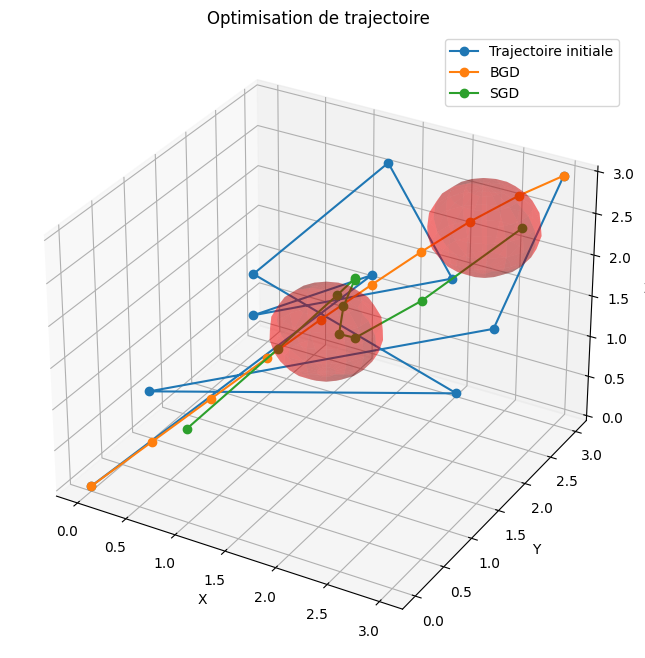

In [7]:
fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(111, projection='3d')

# Trajectoire initiale

ax.plot(
    x_init[:,0],
    x_init[:,1],
    x_init[:,2],
    'o-',
    label='Trajectoire initiale'
)

# BGD

ax.plot(
    x_bgd[:,0],
    x_bgd[:,1],
    x_bgd[:,2],
    'o-',
    label='BGD'
)

# SGD

ax.plot(
    x_sgd[:,0],
    x_sgd[:,1],
    x_sgd[:,2],
    'o-',
    label='SGD'
)

# Obstacles

for obstacle in obstacles:

    u, v = np.mgrid[
        0:2*np.pi:20j,
        0:np.pi:10j
    ]

    x = (
        obstacle["center"][0]
        + obstacle["radius"]
        * np.sin(u)
        * np.cos(v)
    )

    y = (
        obstacle["center"][1]
        + obstacle["radius"]
        * np.sin(u)
        * np.sin(v)
    )

    z = (
        obstacle["center"][2]
        + obstacle["radius"]
        * np.cos(u)
    )

    ax.plot_surface(
        x,
        y,
        z,
        color='r',
        alpha=0.3
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend()

plt.title(
    "Optimisation de trajectoire"
)

plt.show()

<a name='5'></a>

### 5. Analyse expérimentale
**Question 4**
Comparer entre BGD et SGD :
- la vitesse de convergence ;
- la stabilité ;
- la qualité de la trajectoire finale.

**Question 5**
Modifier le taux d’apprentissage :
$$\eta = 0.1,\quad 0.01,\quad 0.001$$
Que se passe-t-il ?

**Question 6**
Modifier les paramètres et interpréter les résultats :
- $\alpha$
- $\beta$
- $\gamma$

<a name='6'></a>

### 6. Conclusion

**Résultats attendus** :
Les étudiants doivent observer que :
* la trajectoire devient plus lisse ;
* les obstacles sont évités ;
* BGD est plus stable ;
* SGD est plus bruité mais parfois plus rapide ;
* le choix du learning rate est crucial.

Dans ce TP, nous avons :
* construit un problème réel d’optimisation ;
* formulé une fonction objectif ;
* étudié l’existence et l’unicité ;
* implémenté :
    * le gradient ;
    * la descente de gradient batch ;
    * la descente de gradient stochastique ;
* visualisé les trajectoires optimisées.